### **[중고차 특징 기반 의심 차량 예측 모델]** <hr>
- 데이터 출처: https://www.kaggle.com/datasets/ananaymital/us-used-cars-dataset

#### **[1] 분석에 필요한 피쳐와 타겟 정제** <hr>

[1-1] 데이터 프레임 구조 파악

In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv('../Data/used_cars_data.csv', low_memory=False)

df.head(3)

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,...,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
0,ZACNJABB5KPJ92081,35.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,Bayamon,NaN,NaN,...,A,9-Speed Automatic Overdrive,t83804,Latitude FWD,NaN,FWD,Front-Wheel Drive,101.2 in,79.6 in,2019
1,SALCJ2FX1LH858117,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
2,JF1VA2M67G9829723,35.4 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,17.0,NaN,...,M,6-Speed Manual,t58994,Base,NaN,AWD,All-Wheel Drive,104.3 in,78.9 in,2016


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 66 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   vin                      str    
 1   back_legroom             str    
 2   bed                      str    
 3   bed_height               str    
 4   bed_length               str    
 5   body_type                str    
 6   cabin                    str    
 7   city                     str    
 8   city_fuel_economy        float64
 9   combine_fuel_economy     float64
 10  daysonmarket             int64  
 11  dealer_zip               str    
 12  description              str    
 13  engine_cylinders         str    
 14  engine_displacement      float64
 15  engine_type              str    
 16  exterior_color           str    
 17  fleet                    object 
 18  frame_damaged            object 
 19  franchise_dealer         bool   
 20  franchise_make           str    
 21  front_legroom      

[1-2] 필요한 컬럼 정의

In [10]:
target_cols = [
    "has_accidents",
    "frame_damaged",
    "salvage",
    "theft_title",
]

feature_cols = [
    # 사용 이력 / 상태
    "mileage",
    "owner_count",
    "daysonmarket",

    # 가격 / 시장 반응
    "price",
    "savings_amount",

    # 성능 / 구조
    "horsepower",
    "engine_displacement",
    "engine_type",
    "engine_cylinders",
    "fuel_type",

    # 차량 설계 / 구동
    "body_type",
    "wheel_system",
    "transmission",

    # 위치 / 판매 환경
    "city",
    "dealer_zip",
    "seller_rating",
    "franchise_dealer",

    # 텍스트 정보
    "description",
    "major_options",
]

In [ ]:
df_needed = df[feature_cols + target_cols].copy()

## 타겟 컬럼 결측치를 False로 표기 / True이면 명시했을 것이라고 판단
bool_cols = ["has_accidents", "frame_damaged", "salvage", "theft_title"]
df_needed[bool_cols] = df_needed[bool_cols].fillna(False)

## 타겟 컬럼을 bool 타입으로 변환
for col in target_cols:
    df_needed[col] = df_needed[col].astype(bool)
    print(df_needed[col].value_counts())
    print("-" * 30)

has_accidents
False    2757086
True      242954
Name: count, dtype: int64
------------------------------
frame_damaged
False    2985089
True       14951
Name: count, dtype: int64
------------------------------
salvage
False    2989513
True       10527
Name: count, dtype: int64
------------------------------
theft_title
False    2994774
True        5266
Name: count, dtype: int64
------------------------------


In [27]:
df_needed.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   mileage              float64
 1   owner_count          float64
 2   daysonmarket         int64  
 3   price                float64
 4   savings_amount       int64  
 5   horsepower           float64
 6   engine_displacement  float64
 7   engine_type          str    
 8   engine_cylinders     str    
 9   fuel_type            str    
 10  body_type            str    
 11  wheel_system         str    
 12  transmission         str    
 13  city                 str    
 14  dealer_zip           str    
 15  seller_rating        float64
 16  franchise_dealer     bool   
 17  description          str    
 18  major_options        str    
 19  has_accidents        bool   
 20  frame_damaged        bool   
 21  salvage              bool   
 22  theft_title          bool   
dtypes: bool(5), float64(6), int64(2), str(10)
m

In [ ]:
## 고윳값이 20개 이하인 컬럼은 모두 category로 변환
be_categorized = []
for col in feature_cols:
    if (df_needed[col].nunique() < 20):
        be_categorized.append(col)
        print(col, df_needed[col].nunique())
        print("-" * 30)
# print(be_categorized)

for col in be_categorized:
    df_needed[col] = df_needed[col].astype('category')

owner_count 18
------------------------------
fuel_type 8
------------------------------
body_type 9
------------------------------
wheel_system 5
------------------------------
transmission 4
------------------------------
franchise_dealer 2
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 23 columns):
 #   Column               Dtype   
---  ------               -----   
 0   mileage              float64 
 1   owner_count          category
 2   daysonmarket         int64   
 3   price                float64 
 4   savings_amount       int64   
 5   horsepower           float64 
 6   engine_displacement  float64 
 7   engine_type          str     
 8   engine_cylinders     str     
 9   fuel_type            category
 10  body_type            category
 11  wheel_system         category
 12  transmission         category
 13  city                 str     
 14  dealer_zip           str     
 15  seller_rating        flo

In [44]:
df_needed['franchise_dealer'] = df_needed['franchise_dealer'].astype(bool)

df_needed[['engine_type', 'engine_cylinders']].value_counts()

## 중복되므로 삭제
df_needed.drop(columns=["engine_cylinders"], inplace=True)

In [47]:
## 필요없는 컬럼 삭제
df_needed.drop(columns=["horsepower", "engine_displacement"], inplace=True)

In [50]:
df_needed.drop(columns=["major_options"], inplace=True)

In [59]:
df_needed.drop(columns=["description"], inplace=True)

In [63]:
df_needed["engine_type"] = df_needed["engine_type"].astype("category")
df_needed["city"] = df_needed["city"].astype("category")

df_needed.drop(columns=["dealer_zip"], inplace=True)


[1-3] 수정된 데이터프레임 확인

In [64]:
df_needed.head(3)

,mileage,owner_count,daysonmarket,price,savings_amount,engine_type,fuel_type,body_type,wheel_system,transmission,city,seller_rating,franchise_dealer,has_accidents,frame_damaged,salvage,theft_title
0,7.0,NaN,522,23141.0,0,I4,Gasoline,SUV / Crossover,FWD,A,Bayamon,2.8,True,False,False,False,False
1,8.0,NaN,207,46500.0,0,I4,Gasoline,SUV / Crossover,AWD,A,San Juan,3.0,True,False,False,False,False
2,NaN,3.0,1233,46995.0,0,H4,Gasoline,Sedan,AWD,M,Guaynabo,NaN,True,False,False,False,False


In [65]:
df_needed.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 17 columns):
 #   Column            Dtype   
---  ------            -----   
 0   mileage           float64 
 1   owner_count       category
 2   daysonmarket      int64   
 3   price             float64 
 4   savings_amount    int64   
 5   engine_type       category
 6   fuel_type         category
 7   body_type         category
 8   wheel_system      category
 9   transmission      category
 10  city              category
 11  seller_rating     float64 
 12  franchise_dealer  bool    
 13  has_accidents     bool    
 14  frame_damaged     bool    
 15  salvage           bool    
 16  theft_title       bool    
dtypes: bool(5), category(7), float64(3), int64(2)
memory usage: 151.7 MB


In [70]:
df_needed.isna().sum()

mileage              144387
owner_count         1517013
daysonmarket              0
price                     0
savings_amount            0
engine_type          100581
fuel_type             82724
body_type             13543
wheel_system         146732
transmission          64185
city                      0
seller_rating         40872
franchise_dealer          0
has_accidents             0
frame_damaged             0
salvage                   0
theft_title               0
dtype: int64

In [77]:
print(df_needed[["mileage", "price"]].describe())
print()

            mileage         price
count  3.000040e+06  3.000040e+06
mean   3.004573e+04  2.993337e+04
std    7.293434e+04  1.956617e+04
min    0.000000e+00  1.650000e+02
25%    6.000000e+00  1.845100e+04
50%    8.267000e+03  2.647700e+04
75%    4.152900e+04  3.822000e+04
max    9.999999e+07  3.299995e+06



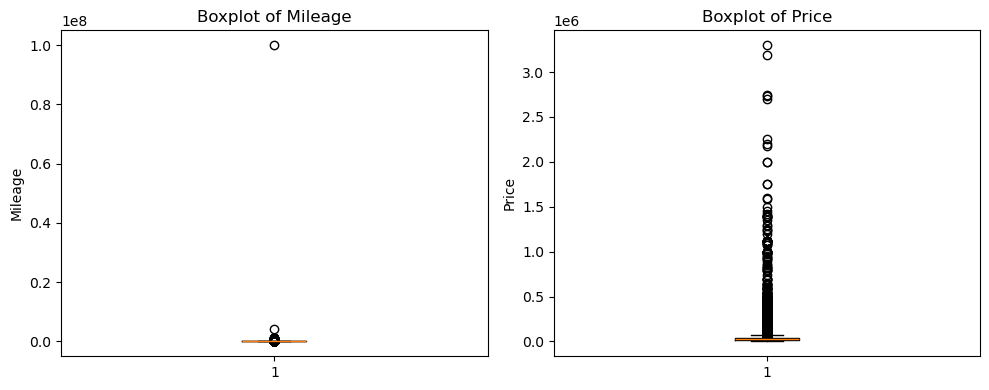

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Mileage boxplot
axes[0].boxplot(df_needed["mileage"].dropna())
axes[0].set_title("Boxplot of Mileage")
axes[0].set_ylabel("Mileage")

# Price boxplot
axes[1].boxplot(df_needed["price"].dropna())
axes[1].set_title("Boxplot of Price")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

> 주행거리와 가격 변수는 이상치가 많아 평균 대신 중앙값으로 대체  
> 범주형 변수의 결측치는 정보 손실을 방지하기 위해 ‘Unknown’ 카테고리로 처리

In [71]:
## 숫자형은 중앙값으로 대체
num_cols = ["mileage", "seller_rating"]


for col in num_cols:
    df_needed[col] = df_needed[col].fillna(df_needed[col].median())

In [ ]:
## 카테고리 컬럼의 결측값은 Unknown으로 채우기
# for col in cat_cols_to_unknown:
#     df_needed[col] = df_needed[col].cat.add_categories("Unknown").fillna("Unknown")

In [111]:
import numpy as np
import pandas as pd

df_needed["owner_count"] = (
    df_needed["owner_count"]
    .astype(str)
    .str.strip()
    .replace({"Unknown": np.nan, "nan": np.nan, "None": np.nan, "": np.nan})
)

df_needed["owner_count"] = pd.to_numeric(df_needed["owner_count"], errors="coerce")

df_needed["owner_count_missing"] = df_needed["owner_count"].isna().astype(int)

df_needed["owner_count"] = (
    df_needed["owner_count"]
    .fillna(-1)
    .astype(int)
)

> 여기서 df_needed 데이터 프레임 (피쳐)을 **df_model.csv** 파일로 새롭게 저장
- mileage
- owner_count
- daysonmarket
- price
- savings_amount
- engine_type
- fuel_type
- body_type
- wheel_system
- transmission
- city
- seller_rating
- franchise_dealer
- owner_count_missing

> **has_accidents**, **frame_damaged**, **salvage**, **theft_title**은 타겟 컬럼 추가 사용을 위해서 df_model.csv파일에서는 제거

#### **[2] 여러 타겟 컬럼들을 종합하여 하나의 int 타입 'suspected' 타겟 컬럼 만들기** <hr>

[2-1] suspected 컬럼을 만들기 위해 필요한 컬럼 추출하기

- 'is_certified', 'is_cpo', 'is_oemcpo', 'is_new' 인증 및 신차 여부도 중요할 것이라 생각하여 추가하였음!

In [2]:
import pandas as pd

df = pd.read_csv('../Data/used_cars_data.csv', usecols=[
    'has_accidents', 'frame_damaged', 'salvage', 'theft_title', 
    'is_certified', 'is_cpo', 'is_oemcpo', 'is_new'])


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   frame_damaged  object 
 1   has_accidents  object 
 2   is_certified   float64
 3   is_cpo         object 
 4   is_new         bool   
 5   is_oemcpo      object 
 6   salvage        object 
 7   theft_title    object 
dtypes: bool(1), float64(1), object(6)
memory usage: 163.1+ MB
None


In [4]:
cols = [
    'has_accidents', 'frame_damaged', 'salvage', 'theft_title', 
    'is_certified', 'is_cpo', 'is_oemcpo', 'is_new'
]

def to_binary(value):
    # 결측치(NaN)인 경우 0으로 처리
    if pd.isna(value):
        return 0
    # True, 'True', 'T', 1, '1' 등을 체크
    if value in [True, 1, 'True', '1', 'T', 't', 'Y', 'y']:
        return 1
    # 나머지는 0 (False, 'False', 0 등)
    return 0

# 3. 데이터프레임에 적용
for col in cols:
    df[col] = df[col].apply(to_binary)

# 4. 타입 강제 지정 (메모리 절약 및 연산 속도 향상)
df[cols] = df[cols].astype(int)

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 8 columns):
 #   Column         Dtype
---  ------         -----
 0   frame_damaged  int64
 1   has_accidents  int64
 2   is_certified   int64
 3   is_cpo         int64
 4   is_new         int64
 5   is_oemcpo      int64
 6   salvage        int64
 7   theft_title    int64
dtypes: int64(8)
memory usage: 183.1 MB
None
   frame_damaged  has_accidents  is_certified  is_cpo  is_new  is_oemcpo  \
0              0              0             0       0       1          0   
1              0              0             0       0       1          0   
2              0              0             0       0       0          0   
3              0              0             0       0       1          0   
4              0              0             0       0       1          0   

   salvage  theft_title  
0        0            0  
1        0            0  
2        0            0  
3        0            0  
4      

[2-2] 조건식으로 suspected 컬럼 만들기
- 'is_certified', 'is_cpo', 'is_oemcpo' 모두 같은 의미이므로 'is_cpo'만 사용

In [5]:
import numpy as np

# 1. 중대 사고 여부 (하나라도 있으면 True)
# frame_damaged, salvage, theft_title 중 하나라도 1인 경우
major_risk = (df['frame_damaged'] == 1) | (df['salvage'] == 1) | (df['theft_title'] == 1)

# 2. 일반 사고 중 '의심'되는 경우 
# (사고가 있는데 인증 중고차도 아니고 CPO도 아닌 경우 -> 정밀도 향상 포인트)
general_risk_strict = (df['has_accidents'] == 1) & (df['is_certified'] == 0) & (df['is_cpo'] == 0)

# 3. 신차인데 이력이 있는 데이터 오류 케이스
new_car_anomaly = (df['is_new'] == 1) & ((df['has_accidents'] == 1) | major_risk)

# 4. 최종 suspected 결정 (OR 연산)
# 위 세 조건 중 하나라도 해당하면 1, 아니면 0
df['suspected'] = np.where(major_risk | general_risk_strict | new_car_anomaly, 1, 0)

# 결과 확인
print(df['suspected'].value_counts())

suspected
0    2755934
1     244106
Name: count, dtype: int64


In [6]:
for col in cols:
    print(df[col].value_counts())

has_accidents
0    2757086
1     242954
Name: count, dtype: int64
frame_damaged
0    2985089
1      14951
Name: count, dtype: int64
salvage
0    2989513
1      10527
Name: count, dtype: int64
theft_title
0    2994774
1       5266
Name: count, dtype: int64
is_certified
0    3000040
Name: count, dtype: int64
is_cpo
0    2817142
1     182898
Name: count, dtype: int64
is_oemcpo
0    2864678
1     135362
Name: count, dtype: int64
is_new
0    1529003
1    1471037
Name: count, dtype: int64


#### **[3] 최종 분석하고자 하는 데이터 프레임 완성하기** <hr>

[3-1] 피쳐와 타겟 합치기

In [7]:
import pandas as pd

df_model = pd.read_csv("df_model.csv")

## 합치기
df_model['suspected'] = df['suspected']

# category 컬럼
cat_cols = [
    "engine_type", "fuel_type", "body_type",
    "wheel_system", "transmission", "city"
]
df_model[cat_cols] = df_model[cat_cols].astype("category")

# bool 컬럼
bool_cols = [
    "franchise_dealer"
]

df_model.drop(columns="owner_count_missing", inplace=True)

df_model[bool_cols] = df_model[bool_cols].astype(bool)

In [8]:
#df_model = df_model.drop(columns='suspected')

In [9]:
print(df_model.info())
print()
print(df_model.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 14 columns):
 #   Column            Dtype   
---  ------            -----   
 0   mileage           int64   
 1   owner_count       int64   
 2   daysonmarket      int64   
 3   price             int64   
 4   savings_amount    int64   
 5   engine_type       category
 6   fuel_type         category
 7   body_type         category
 8   wheel_system      category
 9   transmission      category
 10  city              category
 11  seller_rating     float64 
 12  franchise_dealer  bool    
 13  suspected         int64   
dtypes: bool(1), category(6), float64(1), int64(6)
memory usage: 183.1 MB
None

   mileage  owner_count  daysonmarket  price  savings_amount engine_type  \
0        7           -1           522  23141               0          I4   
1        8           -1           207  46500               0          I4   
2     8267            3          1233  46995               0          H4   

 

> 사용하고 싶은 데이터프레임의 피쳐와 타겟 전처리 완료

In [10]:
all_cols = df_model.columns
for col in all_cols:
    print(df_model[col].value_counts())

mileage
0         256899
5         150881
8267      144402
10        139482
3          78297
           ...  
328727         1
131912         1
387347         1
180525         1
121932         1
Name: count, Length: 197577, dtype: int64
owner_count
-1     1517013
 1      972936
 2      330624
 3      116775
 4       39764
 5       14207
 6        5286
 7        1977
 8         836
 9         366
 10        128
 11         73
 12         21
 13         16
 14          7
 15          6
 16          3
 19          1
 18          1
Name: count, dtype: int64
daysonmarket
8       73158
7       72604
6       69285
13      58356
14      58340
        ...  
1353        1
2227        1
1515        1
1283        1
996         1
Name: count, Length: 1754, dtype: int64
price
8995      8471
9995      8433
7995      8207
14995     7803
16995     7583
          ... 
108560       1
115025       1
64014        1
76567        1
73108        1
Name: count, Length: 87835, dtype: int64
savings_amount
0     

#### **[4] 피쳐와 타겟 분리** <hr>

In [ ]:
X = df_model.drop(columns=["suspected"])
y = df_model["suspected"]

# split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 컬럼 분리
cat_cols = X_train.select_dtypes(include="category").columns
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns


In [12]:
## 의심 차량, 아닌 차량 비율 비슷함!
df_model[df_model["suspected"] == 0]

,mileage,owner_count,daysonmarket,price,savings_amount,engine_type,fuel_type,body_type,wheel_system,transmission,city,seller_rating,franchise_dealer,suspected
0,7,-1,522,23141,0,I4,Gasoline,SUV / Crossover,FWD,A,Bayamon,2.800000,True,0
1,8,-1,207,46500,0,I4,Gasoline,SUV / Crossover,AWD,A,San Juan,3.000000,True,0
2,8267,3,1233,46995,0,H4,Gasoline,Sedan,AWD,M,Guaynabo,4.341463,True,0
3,11,-1,196,67430,0,V6,Gasoline,SUV / Crossover,AWD,A,San Juan,3.000000,True,0
4,7,-1,137,48880,0,I4,Gasoline,SUV / Crossover,AWD,A,San Juan,3.000000,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000034,20009,1,89,40993,2220,V6,Gasoline,Pickup Truck,4WD,A,Ukiah,5.000000,True,0
3000035,41897,1,16,17998,381,I4,Gasoline,SUV / Crossover,FWD,A,Fairfield,4.272727,False,0
3000036,5,-1,171,36490,0,V6,Gasoline,SUV / Crossover,FWD,A,Vallejo,4.533333,True,0
3000038,27857,1,11,26998,849,I4 Diesel,Diesel,Sedan,AWD,A,Fairfield,4.272727,False,0


In [13]:
df_model['owner_count'].value_counts()

owner_count
-1     1517013
 1      972936
 2      330624
 3      116775
 4       39764
 5       14207
 6        5286
 7        1977
 8         836
 9         366
 10        128
 11         73
 12         21
 13         16
 14          7
 15          6
 16          3
 19          1
 18          1
Name: count, dtype: int64

#### **[5] 머신러닝 분석 수행** <hr>

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

## 카테고리형은 onehot, 숫자형은 standard scaler 적용
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

## LogisticRegression(분류) 알고리즘 적용
model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])


In [15]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.78      0.87    551187
           1       0.24      0.82      0.38     48821

    accuracy                           0.78    600008
   macro avg       0.61      0.80      0.62    600008
weighted avg       0.92      0.78      0.83    600008



**정상 차량(0)**

precision 0.98 -> 정상이라고 한 건 거의 진짜 정상  
recall 0.78 -> 정상 차량을 꽤 의심으로 보내버림

**의심 차량(1)**

precision 0.24 -> 많이 의심함!!  
recall 0.82 -> 거의 안 놓침  

#### **[6] 딥러닝 분석 수행** <hr>

In [17]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

target_col = "suspected"

cat_cols = df_model.select_dtypes(include=["category"]).columns.tolist()
num_cols = df_model.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]  # 타깃 제외

print("cat_cols:", cat_cols)
print("num_cols:", num_cols)

# category -> codes (0..n-1), 결측(-1)은 0번으로 보내고, 카테고리 수 +1 (UNK) 처리
cat_cardinalities = {}
for c in cat_cols:
    df_model[c] = df_model[c].cat.add_categories(["__UNK__"]) if "__UNK__" not in df_model[c].cat.categories else df_model[c]
    df_model[c] = df_model[c].fillna("__UNK__")

    cat_cardinalities[c] = df_model[c].cat.categories.size


cat_cols: ['engine_type', 'fuel_type', 'body_type', 'wheel_system', 'transmission', 'city']
num_cols: ['mileage', 'owner_count', 'daysonmarket', 'price', 'savings_amount', 'seller_rating', 'franchise_dealer']


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

idx = np.arange(len(df_model))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=df_model[target_col].values
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.25,  # (남은 80%)의 25% = 전체의 20%
    random_state=42,
    stratify=df_model.loc[train_idx, target_col].values
)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(df_model.loc[train_idx, num_cols].astype(float))
X_num_val   = scaler.transform(df_model.loc[val_idx, num_cols].astype(float))
X_num_test  = scaler.transform(df_model.loc[test_idx, num_cols].astype(float))

with open('./scaler_juyeong.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# category codes
def cat_codes(df, cols):
    arrs = []
    for c in cols:
        codes = df[c].cat.codes.to_numpy()
        # codes가 -1이면 (결측/미정) -> 마지막 카테고리(__UNK__) 코드로 보내기
        unk_code = df[c].cat.categories.get_loc("__UNK__") if "__UNK__" in df[c].cat.categories else (df[c].cat.categories.size - 1)
        codes = np.where(codes < 0, unk_code, codes)
        arrs.append(codes.astype(np.int64))
    return np.stack(arrs, axis=1) if len(arrs) > 0 else np.zeros((len(df), 0), dtype=np.int64)

X_cat_train = cat_codes(df_model.loc[train_idx], cat_cols)
X_cat_val   = cat_codes(df_model.loc[val_idx], cat_cols)
X_cat_test  = cat_codes(df_model.loc[test_idx], cat_cols)

y_train = df_model.loc[train_idx, target_col].astype(int).to_numpy()
y_val   = df_model.loc[val_idx, target_col].astype(int).to_numpy()
y_test  = df_model.loc[test_idx, target_col].astype(int).to_numpy()

In [ ]:
class TabDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y     = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return (self.X_num[i], self.X_cat[i]), self.y[i]

batch_size = 2048
train_ds = TabDataset(X_num_train, X_cat_train, y_train)
val_ds   = TabDataset(X_num_val,   X_cat_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

test_ds  = TabDataset(X_num_test, X_cat_test, y_test)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)


In [20]:
import torch.nn as nn
import torch.nn.functional as F

class TabularDNN(nn.Module):
    def __init__(self, cat_cardinalities: dict, num_dim: int,
                 emb_dim_rule="auto",
                 hidden_dims=(256, 128),
                 dropout=0.2,
                 n_classes=2):
        super().__init__()

        self.cat_cols = list(cat_cardinalities.keys())
        self.num_dim = num_dim

        # Embedding layers
        self.embs = nn.ModuleList()
        emb_out_dim_total = 0

        for c in self.cat_cols:
            n_cat = cat_cardinalities[c]
            if emb_dim_rule == "auto":
                # 흔한 규칙: min(50, round(sqrt(n_cat)) + 1)
                d = int(min(50, round(np.sqrt(n_cat)) + 1))
            else:
                d = int(emb_dim_rule)
            self.embs.append(nn.Embedding(n_cat, d))
            emb_out_dim_total += d

        in_dim = num_dim + emb_out_dim_total

        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, n_classes)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        x_num, x_cat = x  # x_cat: (B, n_cat_cols)
        embs = []
        for i, emb in enumerate(self.embs):
            embs.append(emb(x_cat[:, i]))
        x_emb = torch.cat(embs, dim=1) if len(embs) > 0 else torch.empty((x_num.size(0), 0), device=x_num.device)
        x_all = torch.cat([x_num, x_emb], dim=1)
        logits = self.mlp(x_all)
        return logits


In [21]:
import sys
import os
sys.path.append(os.path.abspath("../Utils"))
import util_func as uf

device = "cuda" if torch.cuda.is_available() else "cpu"

# class weights
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
w0 = 1.0
w1 = neg / max(pos, 1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=device)

model = TabularDNN(cat_cardinalities, num_dim=len(num_cols), hidden_dims=(256, 128), dropout=0.3).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

ALL_MODEL = './all_model.pt'    # 모델 전체 확장자 주로 pt로 사용
WEIGHTS_MODEL = './weights'     # 파라미터 저장 확장자 pth
BEST_LOSS = 100.0
epochs = 5

for ep in range(1, epochs + 1):
    tr_loss, tr_acc = uf.train_one_epoch(model, train_loader, loss_fn, optim, device)
    va_loss, va_acc = uf.evaluate(model, val_loader, loss_fn, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if BEST_LOSS > va_loss:
        #- 모델 전체 저장
        torch.save(model, ALL_MODEL)
        #- 파라미터만 저장
        torch.save(model.state_dict(), f"./{WEIGHTS_MODEL}_{ep:03}_{va_loss:.5f}.pth")
        #- 기준 loss 점수 업데이트
        BEST_LOSS = va_loss

    print(f"[Epoch {ep}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")


[Epoch 1] train_loss=0.4129 train_acc=0.7172 | val_loss=0.3968 val_acc=0.7422
[Epoch 2] train_loss=0.3963 train_acc=0.7296 | val_loss=0.3918 val_acc=0.7405
[Epoch 3] train_loss=0.3910 train_acc=0.7346 | val_loss=0.3897 val_acc=0.7301
[Epoch 4] train_loss=0.3875 train_acc=0.7374 | val_loss=0.3880 val_acc=0.7321
[Epoch 5] train_loss=0.3852 train_acc=0.7383 | val_loss=0.3869 val_acc=0.7379


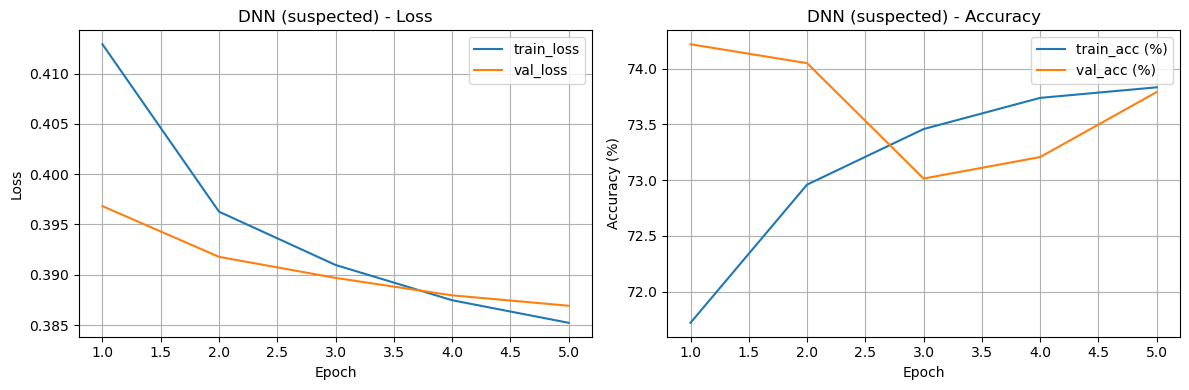

In [22]:
uf.plot_history(history, title="DNN (suspected)")

In [23]:
from sklearn.metrics import classification_report

@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()
    probs = []
    trues = []
    for (x_num, x_cat), y in loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        logits = model((x_num, x_cat))
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.append(p)
        trues.append(y.numpy())
    return np.concatenate(probs), np.concatenate(trues)

probs, trues = predict_all(model, val_loader, device)
preds = (probs >= 0.5).astype(int)  # threshold 조정 가능
print(classification_report(trues, preds))

              precision    recall  f1-score   support

           0       0.99      0.72      0.84    551187
           1       0.22      0.90      0.36     48821

    accuracy                           0.74    600008
   macro avg       0.61      0.81      0.60    600008
weighted avg       0.93      0.74      0.80    600008



In [24]:
from sklearn.metrics import classification_report

for th in [0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = (probs >= th).astype(int)
    print("\nTH =", th)
    print(classification_report(trues, preds, digits=3))


TH = 0.5
              precision    recall  f1-score   support

           0      0.988     0.724     0.835    551187
           1      0.224     0.899     0.358     48821

    accuracy                          0.738    600008
   macro avg      0.606     0.811     0.597    600008
weighted avg      0.926     0.738     0.797    600008


TH = 0.6
              precision    recall  f1-score   support

           0      0.979     0.801     0.881    551187
           1      0.263     0.804     0.397     48821

    accuracy                          0.801    600008
   macro avg      0.621     0.802     0.639    600008
weighted avg      0.921     0.801     0.842    600008


TH = 0.7
              precision    recall  f1-score   support

           0      0.968     0.862     0.912    551187
           1      0.305     0.681     0.421     48821

    accuracy                          0.847    600008
   macro avg      0.636     0.772     0.667    600008
weighted avg      0.914     0.847     0.872 

검증데이터로 했을 때: threshold 조정에 따라 precision–recall trade-off가 뚜렷하게 나타났으며, support는 동일한 검증 데이터 기준이므로 모든 threshold에서 일정하게 유지됨.

TH=0.6은 의심 차량을 놓치지 않으면서(Recall 유지) 오탐을 유의미하게 줄이는 지점

ML모델 대비 precision이 약 24% 개선

In [25]:
probs_test, trues_test = predict_all(model, test_loader, device)

TH = 0.6 
preds_test = (probs_test >= TH).astype(int)

print(classification_report(trues_test, preds_test, digits=3))

              precision    recall  f1-score   support

           0      0.979     0.800     0.881    551187
           1      0.263     0.803     0.396     48821

    accuracy                          0.801    600008
   macro avg      0.621     0.802     0.638    600008
weighted avg      0.920     0.801     0.841    600008



**테스트케이스 3개로 예측!**

In [44]:
import random
import torch
import numpy as np

@torch.no_grad()
def predict_random_test_cases(
    model, test_ds, device, threshold=0.6, n_samples=3
):
    model.eval()

    idxs = random.sample(range(len(test_ds)), n_samples)

    print(f"\n[Test sample predictions | TH={threshold}]")
    print("-" * 60)

    for i, idx in enumerate(idxs, 1):
        (x_num, x_cat), y_true = test_ds[idx]

        x_num = x_num.unsqueeze(0).to(device)
        x_cat = x_cat.unsqueeze(0).to(device)

        logits = model((x_num, x_cat))
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        y_pred = int(prob >= threshold)

        print(f"[Case {i}]")
        print(f"True label      : {y_true.item()} ({'Suspected' if y_true==1 else 'Normal'})")
        print(f"Predicted prob  : {prob:.4f}")
        print(f"Predicted label: {y_pred} ({'Suspected' if y_pred==1 else 'Normal'})")
        print("-" * 60)

predict_random_test_cases(
    model,
    test_ds,
    device,
    threshold=0.6, 
    n_samples=3
)


[Test sample predictions | TH=0.6]
------------------------------------------------------------
[Case 1]
True label      : 0 (Normal)
Predicted prob  : 0.0006
Predicted label: 0 (Normal)
------------------------------------------------------------
[Case 2]
True label      : 1 (Suspected)
Predicted prob  : 0.9589
Predicted label: 1 (Suspected)
------------------------------------------------------------
[Case 3]
True label      : 0 (Normal)
Predicted prob  : 0.1429
Predicted label: 0 (Normal)
------------------------------------------------------------


#### **[7] 예측 모델 사용을 위한 모델 추출** <hr>

In [ ]:
## 카테고리 매핑정보 저장
cat_mapping = {
    c: df_model[c].cat.categories.tolist()
    for c in cat_cols
}

with open("./cat_mapping.pkl", "wb") as f:
    pickle.dump(cat_mapping, f)

In [46]:
## 모델 구조정보 저장

model_config = {
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "cat_cardinalities": cat_cardinalities,
    "hidden_dims": (256, 128),
    "dropout": 0.3,
    "threshold": 0.6
}

with open("./model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)
